In [16]:
pip install tensorflow==2.15.0 --upgrade

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 82.9 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 70.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.6 MB/s  0:00:00
  Attempting uninstall: ml-dtypes━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/9 [oauthlib]
    Found existing installation: ml_dtypes 0.5.3━━━━━━━━━━━━━━ 1/9 [oauthlib]
    Uninstalling ml_dtypes-0.5.3:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/9 [oauthlib]
      Successfully uninstalled ml_dtypes-0.5.3━━━━━━━━━━━━━━━━ 1/9 [oauthlib]
  Attempting uninstall: kerasm━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/9 [ml-dtypes]
    Found existing installation: keras 3.9.0━━━━━━━━━━━━━━━━━━ 2/9 [ml-dtypes]
    Uninstalling keras-3.9.0:m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/9 [keras]
      Successfully uninstalled keras-3.9.0━━━━━━━━━━━━━━━━━━━━ 3/9

In [1]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-06-15 00:08:40.488654: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-15 00:08:40.488716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-15 00:08:40.489908: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-15 00:08:40.497117: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-15 00:08:42.462993: W tensorflow/compiler/tf2

TF version: 2.15.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import numpy as np
import os, gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras.layers as layers
from tensorflow.keras import backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f" {len(gpus)} GPU(s) found")
else:
    print("  No GPU — running on CPU")

os.makedirs("./results_age_video", exist_ok=True)

2026-07-01 19:16:14.956515: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 19:16:14.956593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 19:16:14.982574: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 19:16:15.049587: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-01 19:16:29.956218: W tensorflow/compiler/tf2

Your GPU may run slowly with dtype policy mixed_float16 because it does not have compute capability of at least 7.0. Your GPU:
  Tesla P100-PCIE-16GB, compute capability 6.0
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
Mixed precision enabled
 1 GPU(s) found


In [3]:
PREFIX = "GM_Processed_Old_Folders"
SUFFIX = "_497"

paths      = np.load(f"./{PREFIX}_paths{SUFFIX}.npy", allow_pickle=True)
names      = np.array([os.path.basename(p) for p in paths])
dataY      = np.array([1 if "5w" in n else 0 for n in names])
tsData     = np.load(f"./{PREFIX}_tsDataMSE{SUFFIX}.npy")
framesData = np.load(f"./{PREFIX}_framesDataMSE{SUFFIX}.npy")

clipLen = 96
print(f"n={len(paths)}, 1-week={np.sum(dataY==0)}, 5-week={np.sum(dataY==1)}")
print(f"framesData: {framesData.shape}, tsData: {tsData.shape}")

n=497, 1-week=277, 5-week=220
framesData: (497, 256, 512, 128), tsData: (497, 3000)


In [4]:
total_samps = len(paths)
periods = np.zeros((total_samps, clipLen - 1), dtype=np.float32)

for i, ts in enumerate(tsData):
    binarized    = (ts > 0.5).astype(int)
    steps        = np.array([binarized[j] - binarized[j+1] for j in range(len(binarized)-1)])
    nonzero      = np.where(steps != 0)[0]
    selectedidxs = np.array([(nonzero[j] + nonzero[j+1]) // 2 for j in range(len(nonzero)-1)], dtype=np.int32)
    while len(selectedidxs) < clipLen:
        selectedidxs = np.concatenate((selectedidxs, selectedidxs))
    selectedidxs   = selectedidxs[:clipLen]
    periods[i, :] = np.array([selectedidxs[j+1] - selectedidxs[j] for j in range(clipLen-1)])

periods /= 100.0
print("Periods generated:", periods.shape)

Periods generated: (497, 95)


In [6]:
# Exactly matching original architecture
# Only additions: Dropout(0.3) which was already in original Cell 21/22

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision float16 enabled")

def build_combined_model(clipLen=96):
    ts_input     = layers.Input((clipLen-1, 1), name="ts_input")
    frames_input = layers.Input((256, 512, clipLen), name="frames_input")

    x = layers.Conv2D(4,  (3,7), padding='same', activation='relu')(frames_input)
    x = layers.Conv2D(8,  (3,7), padding='same', activation='relu')(x)
    x = layers.MaxPool2D(pool_size=4)(x)
    x = layers.Conv2D(16, (3,7), padding='same', activation='relu')(x)
    x = layers.Conv2D(32, (3,7), padding='same', activation='relu')(x)
    x = layers.MaxPool2D(pool_size=4)(x)
    x = layers.Conv2D(64, (3,7), padding='same', activation='relu')(x)  # ONE only
    x = layers.MaxPool2D(pool_size=4)(x)
    x = layers.Flatten()(x)

    ts_flat  = layers.Flatten()(ts_input)
    combined = layers.Concatenate()([ts_flat, x])
    d = layers.Dense(32, activation='relu')(combined)
    d = layers.Dense(16, activation='relu')(d)
    d = layers.Dense(8,  activation='relu')(d)
    d = layers.Dropout(0.3)(d)
    out = layers.Dense(1, activation='sigmoid', dtype='float32')(d)
    return tf.keras.Model(inputs=[ts_input, frames_input], outputs=out)


def build_video_only_model(clipLen=96):
    frames_input = layers.Input((256, 512, clipLen), name="frames_input")

    x = layers.Conv2D(4,  (3,7), padding='same', activation='relu')(frames_input)
    x = layers.Conv2D(8,  (3,7), padding='same', activation='relu')(x)
    x = layers.MaxPool2D(pool_size=4)(x)
    x = layers.Conv2D(16, (3,7), padding='same', activation='relu')(x)
    x = layers.Conv2D(32, (3,7), padding='same', activation='relu')(x)
    x = layers.MaxPool2D(pool_size=4)(x)
    x = layers.Conv2D(64, (3,7), padding='same', activation='relu')(x)  # ONE only
    x = layers.MaxPool2D(pool_size=4)(x)
    x = layers.Flatten()(x)

    d = layers.Dense(32, activation='relu')(x)
    d = layers.Dense(16, activation='relu')(d)
    d = layers.Dense(8,  activation='relu')(d)
    d = layers.Dropout(0.3)(d)
    out = layers.Dense(1, activation='sigmoid', dtype='float32')(d)
    return tf.keras.Model(inputs=frames_input, outputs=out)


def build_ts_only_model(clipLen=96):
    ts_input = layers.Input((clipLen-1, 1), name="ts_input")
    ts_flat  = layers.Flatten()(ts_input)
    d = layers.Dense(64, activation='relu')(ts_flat)
    d = layers.Dense(32, activation='relu')(d)
    d = layers.Dense(16, activation='relu')(d)
    d = layers.Dropout(0.3)(d)
    out = layers.Dense(1, activation='sigmoid', dtype='float32')(d)
    return tf.keras.Model(inputs=ts_input, outputs=out)

print(" Model definitions ready")

Mixed precision float16 enabled
 Model definitions ready


In [6]:
def bootstrap_ci(y_true, y_pred_proba, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    accs, aucs_b = [], []
    for _ in range(n_boot):
        idx  = rng.integers(0, n, size=n)
        yt_b = y_true[idx]
        yp_b = y_pred_proba[idx]
        if len(np.unique(yt_b)) < 2:
            continue
        accs.append(np.mean((yp_b >= 0.5).astype(int) == yt_b))
        fpr_b, tpr_b, _ = roc_curve(yt_b, yp_b)
        aucs_b.append(auc(fpr_b, tpr_b))
    return (np.percentile(accs,2.5), np.percentile(accs,97.5)), \
           (np.percentile(aucs_b,2.5), np.percentile(aucs_b,97.5))

In [7]:
from sklearn.utils import class_weight as cw

EPOCHS    = 75
BATCHSIZE = 2
LR        = 1e-5

def run_kfold(model_type="combined"):
    skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    splits = list(skf.split(np.arange(total_samps), dataY))
    stats, all_pred_rows = [], []

    for k, (train_idx, test_idx) in enumerate(splits, start=1):
        print(f"\n  === {model_type.upper()} | Fold {k}/5 ===")

        train_frames = framesData[train_idx,:,:,:clipLen].astype(np.float32)/255.0
        test_frames  = framesData[test_idx, :,:,:clipLen].astype(np.float32)/255.0
        train_p = np.expand_dims(periods[train_idx,:], axis=-1)
        test_p  = np.expand_dims(periods[test_idx, :], axis=-1)
        trainY, testY = dataY[train_idx], dataY[test_idx]

        # Class weights
        class_weights_array = cw.compute_class_weight('balanced',
                                                       classes=np.unique(trainY),
                                                       y=trainY)
        class_weights_dict = dict(zip(np.unique(trainY), class_weights_array))
        print(f"     Class weights: {class_weights_dict}")

        if model_type == "combined":
            model   = build_combined_model(clipLen)
            x_train = [train_p, train_frames]
            x_test  = [test_p,  test_frames]
        elif model_type == "video_only":
            model   = build_video_only_model(clipLen)
            x_train = train_frames
            x_test  = test_frames
        else:
            model   = build_ts_only_model(clipLen)
            x_train = train_p
            x_test  = test_p

        model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

        ckpt = f"./results_age_video/ckpt_{model_type}_fold{k}.weights.h5"

        # Same callbacks as original — monitor training loss
        model.fit(x_train, trainY,
                  epochs=EPOCHS,
                  batch_size=BATCHSIZE,
                  verbose=0,
                  class_weight=class_weights_dict,
                  callbacks=[
                      tf.keras.callbacks.ModelCheckpoint(
                          ckpt, save_weights_only=True,
                          monitor='loss',        # same as original
                          save_best_only=True,
                          verbose=0),
                      tf.keras.callbacks.ReduceLROnPlateau(
                          monitor='loss',        # same as original
                          factor=0.5, patience=3, min_lr=1e-8)
                  ])

        model.load_weights(ckpt)
        preds = model.predict(x_test, batch_size=BATCHSIZE).flatten()
        score = model.evaluate(x_test, testY, verbose=0)
        fpr, tpr, _ = roc_curve(testY, preds)
        fold_auc = auc(fpr, tpr)
        print(f"     Acc={score[1]:.4f}  AUROC={fold_auc:.4f}")

        stats.append({"Fold":k, "Num Training":len(train_idx),
                      "Num Testing":len(test_idx),
                      "Accuracy":score[1], "AUROC":fold_auc})
        for i in range(len(test_idx)):
            all_pred_rows.append({
                "SampleID": names[test_idx[i]],
                "Test_idx": int(test_idx[i]),
                "Fold":     k,
                "Raw_Pred": float(preds[i]),
                "Label":    int(testY[i])
            })
        del model; K.clear_session(); gc.collect()

    df_stats = pd.DataFrame(stats)
    mean_row = {c: (df_stats[c].mean() if c!="Fold" else "Mean") for c in df_stats.columns}
    std_row  = {c: (df_stats[c].std()  if c!="Fold" else "Std")  for c in df_stats.columns}
    df_stats = pd.concat([df_stats,
                           pd.DataFrame([mean_row]),
                           pd.DataFrame([std_row])], ignore_index=True)

    df_preds = pd.DataFrame(all_pred_rows)
    all_y, all_p = df_preds["Label"].values, df_preds["Raw_Pred"].values
    ci_acc, ci_auc = bootstrap_ci(all_y, all_p)
    fpr_all, tpr_all, _ = roc_curve(all_y, all_p)
    overall_auc = auc(fpr_all, tpr_all)
    overall_acc = np.mean((all_p>=0.5).astype(int)==all_y)

    print(f"\n  {model_type.upper()} SUMMARY")
    print(f"  Overall Acc  = {overall_acc:.4f}  95%CI [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]")
    print(f"  Overall AUROC= {overall_auc:.4f}  95%CI [{ci_auc[0]:.4f}, {ci_auc[1]:.4f}]")
    print(f"  Mean±Std Acc = {df_stats.loc[df_stats['Fold']=='Mean','Accuracy'].values[0]:.4f}"
          f" ± {df_stats.loc[df_stats['Fold']=='Std','Accuracy'].values[0]:.4f}")
    print(f"  Mean±Std AUC = {df_stats.loc[df_stats['Fold']=='Mean','AUROC'].values[0]:.4f}"
          f" ± {df_stats.loc[df_stats['Fold']=='Std','AUROC'].values[0]:.4f}")

    df_stats.to_csv(f"./results_age_video/kfold_stats_{model_type}.csv", index=False)
    df_preds.to_csv(f"./results_age_video/kfold_data_{model_type}.csv",  index=False)
    print(f"  ✅ Saved: ./results_age_video/kfold_stats_{model_type}.csv")

    return {"model_type":model_type,
            "overall_acc":overall_acc, "overall_auc":overall_auc,
            "ci_acc_lo":ci_acc[0], "ci_acc_hi":ci_acc[1],
            "ci_auc_lo":ci_auc[0], "ci_auc_hi":ci_auc[1],
            "mean_acc":df_stats.loc[df_stats['Fold']=='Mean','Accuracy'].values[0],
            "std_acc": df_stats.loc[df_stats['Fold']=='Std', 'Accuracy'].values[0],
            "mean_auc":df_stats.loc[df_stats['Fold']=='Mean','AUROC'].values[0],
            "std_auc": df_stats.loc[df_stats['Fold']=='Std', 'AUROC'].values[0]}, df_preds

print(" run_kfold() defined — ready to train")

✅ run_kfold() defined — ready to train


VIDEO COUNT AND LABEL DISTRIBUTION PER FOLDER

1w_new:
  Total:  96
  1-week: 96  (100.0%)
  5-week: 0  (0.0%)

20211221_30_VIDS:
  Total:  32
  1-week: 16  (50.0%)
  5-week: 16  (50.0%)

5w_new:
  Total:  59
  1-week: 0  (0.0%)
  5-week: 59  (100.0%)

Farah_SOHA_AVI:
  Total:  29
  1-week: 29  (100.0%)
  5-week: 0  (0.0%)

GM_Uploaded:
  Total:  266
  1-week: 136  (51.1%)
  5-week: 130  (48.9%)

Previous:
  Total:  15
  1-week: 0  (0.0%)
  5-week: 15  (100.0%)

MSE SIGNAL QUALITY PER FOLDER
Folder                        Mean      Std      Min      Max    Zero%
------------------------------------------------------------
1w_new                      0.5181   0.3190   0.0000   1.0000     0.0%
20211221_30_VIDS            0.4983   0.2947   0.0000   1.0000     0.0%
5w_new                      0.5151   0.3044   0.0000   1.0000     0.0%
Farah_SOHA_AVI              0.4892   0.3408   0.0000   1.0000     0.0%
GM_Uploaded                 0.4995   0.3085   0.0000   1.0000     0.0%
Previous        

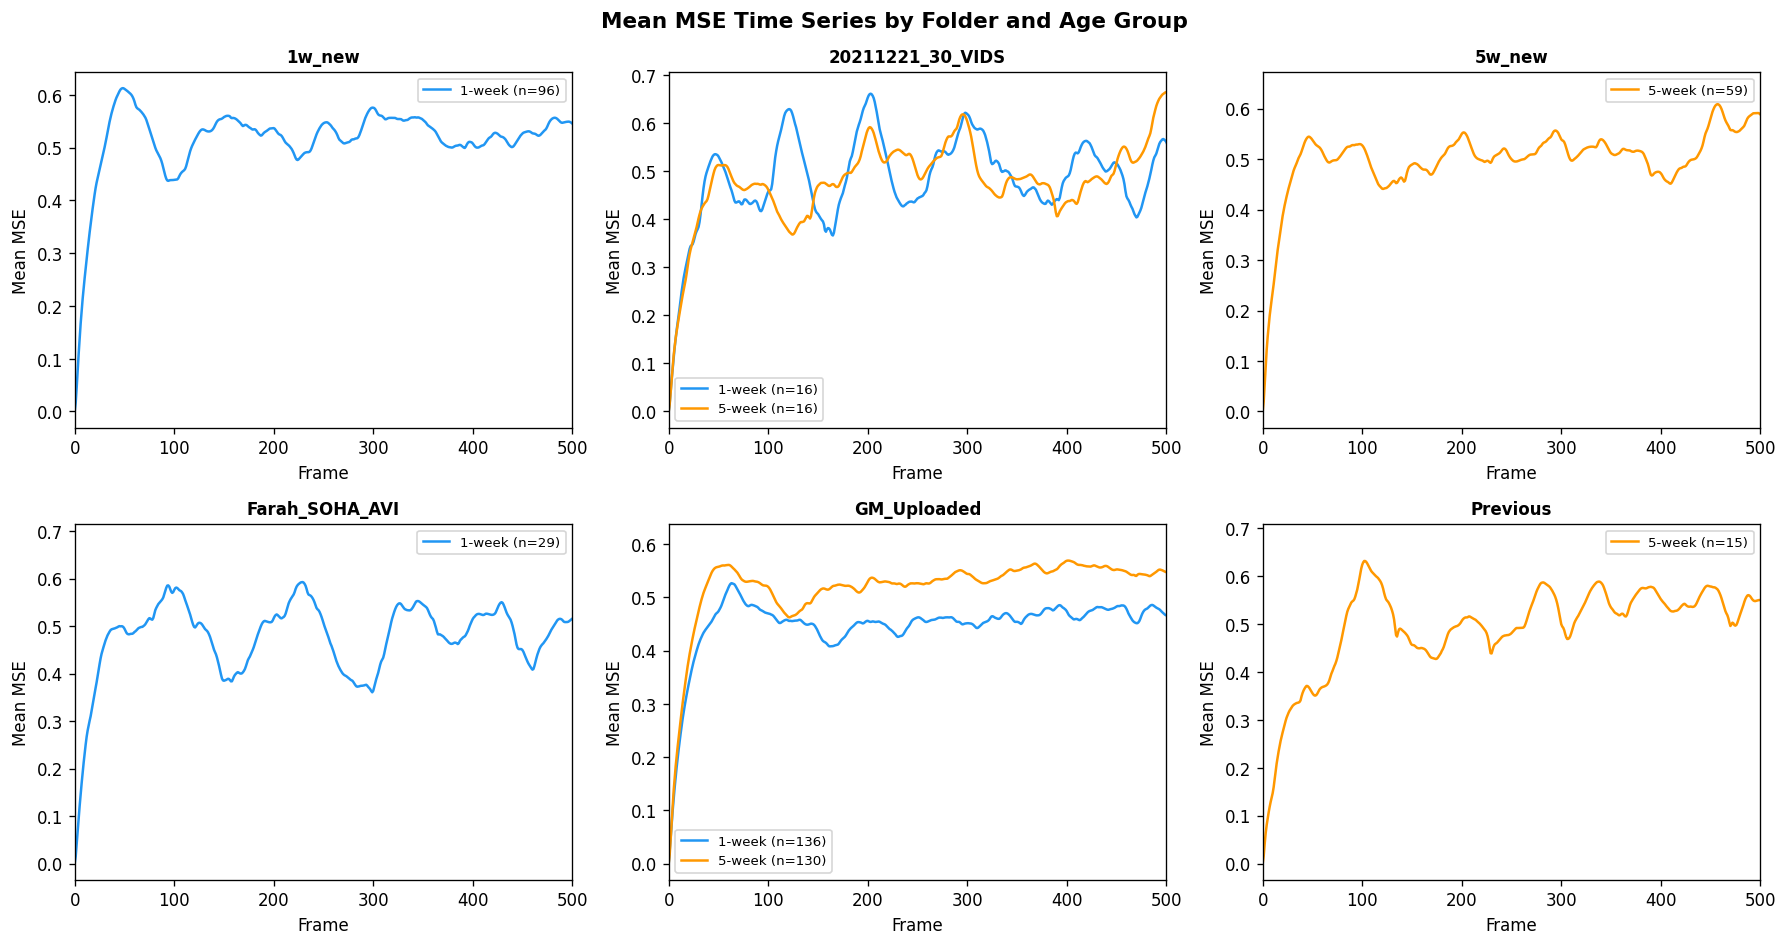


Figure saved: folder_mse_comparison.tiff

FRAME INTENSITY PER FOLDER (batch effect check)
Folder                       Mean px     Std px     Min px     Max px
------------------------------------------------------------
1w_new                         75.72      62.56       0.00     255.00
20211221_30_VIDS               82.63      65.64       0.00     255.00
5w_new                         86.62      63.88       0.00     255.00
Farah_SOHA_AVI                 83.54      68.88       0.00     255.00
GM_Uploaded                    93.23      67.48       0.00     255.00
Previous                       81.07      60.49       0.00     255.00

 Large differences in Mean px between folders = batch effect
 Similar Mean px across folders = no batch effect


In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load paths and labels
paths  = np.load("./GM_Processed_Old_Folders_paths_497.npy", allow_pickle=True)
names  = np.array([os.path.basename(p) for p in paths])
dataY  = np.array([1 if "5w" in n else 0 for n in names])

# Extract folder name for each video
def get_folder(path):
    parts = path.split('/')
    # Find the folder just after 'machine_learning'
    for i, p in enumerate(parts):
        if p == 'machine_learning':
            return parts[i+1]
    return 'unknown'

folders = np.array([get_folder(p) for p in paths])

# ── Stats per folder ──────────────────────────────────────────────
print("="*60)
print("VIDEO COUNT AND LABEL DISTRIBUTION PER FOLDER")
print("="*60)
unique_folders = np.unique(folders)
for f in unique_folders:
    mask   = folders == f
    n_tot  = mask.sum()
    n_1w   = ((dataY == 0) & mask).sum()
    n_5w   = ((dataY == 1) & mask).sum()
    print(f"\n{f}:")
    print(f"  Total:  {n_tot}")
    print(f"  1-week: {n_1w}  ({100*n_1w/n_tot:.1f}%)")
    print(f"  5-week: {n_5w}  ({100*n_5w/n_tot:.1f}%)")

# ── Check MSE signal quality per folder ───────────────────────────
tsData = np.load("./GM_Processed_Old_Folders_tsDataMSE_497.npy")

print("\n" + "="*60)
print("MSE SIGNAL QUALITY PER FOLDER")
print("="*60)
print(f"{'Folder':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Zero%':>8}")
print("-"*60)
for f in unique_folders:
    mask    = folders == f
    ts_fold = tsData[mask]
    # Check what fraction of time series are all zeros (bad videos)
    zero_pct = (ts_fold.max(axis=1) == 0).mean() * 100
    print(f"{f:<25} {ts_fold.mean():>8.4f} {ts_fold.std():>8.4f} "
          f"{ts_fold.min():>8.4f} {ts_fold.max():>8.4f} {zero_pct:>7.1f}%")

# ── Plot MSE distributions per folder ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=120)
axes = axes.flatten()
colors = ['#2196F3','#FF9800','#4CAF50','#E91E63','#9C27B0','#00BCD4']

for i, f in enumerate(unique_folders):
    mask    = folders == f
    ts_fold = tsData[mask]
    ax = axes[i]
    # Plot mean MSE time series for 1w and 5w separately
    mask_1w = mask & (dataY == 0)
    mask_5w = mask & (dataY == 1)
    if mask_1w.sum() > 0:
        ax.plot(tsData[mask_1w].mean(axis=0), 
                color='#2196F3', lw=1.5, label=f'1-week (n={mask_1w.sum()})')
    if mask_5w.sum() > 0:
        ax.plot(tsData[mask_5w].mean(axis=0), 
                color='#FF9800', lw=1.5, label=f'5-week (n={mask_5w.sum()})')
    ax.set_title(f'{f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Mean MSE')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 500)  # show first 500 frames

plt.suptitle('Mean MSE Time Series by Folder and Age Group', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./results_age_video/folder_mse_comparison.tiff', 
            dpi=300, bbox_inches='tight')
plt.show()
print("\nFigure saved: folder_mse_comparison.tiff")

# ── Check for batch effects: frame intensity per folder ────────────
framesData = np.load("./GM_Processed_Old_Folders_framesDataMSE_497.npy")

print("\n" + "="*60)
print("FRAME INTENSITY PER FOLDER (batch effect check)")
print("="*60)
print(f"{'Folder':<25} {'Mean px':>10} {'Std px':>10} {'Min px':>10} {'Max px':>10}")
print("-"*60)
for f in unique_folders:
    mask   = folders == f
    frames = framesData[mask].astype(np.float32)
    print(f"{f:<25} {frames.mean():>10.2f} {frames.std():>10.2f} "
          f"{frames.min():>10.2f} {frames.max():>10.2f}")

print("\n Large differences in Mean px between folders = batch effect")
print(" Similar Mean px across folders = no batch effect")

In [10]:
summary_video, preds_video = run_kfold("video_only")


  === VIDEO_ONLY | Fold 1/5 ===
     Class weights: {0: 0.8981900452488688, 1: 1.1278409090909092}
50/50 [==============================] - 1s 10ms/step
     Acc=0.7600  AUROC=0.7995

  === VIDEO_ONLY | Fold 2/5 ===
     Class weights: {0: 0.8981900452488688, 1: 1.1278409090909092}
50/50 [==============================] - 1s 11ms/step
     Acc=0.8100  AUROC=0.8474

  === VIDEO_ONLY | Fold 3/5 ===
     Class weights: {0: 0.8963963963963963, 1: 1.1306818181818181}
50/50 [==============================] - 1s 11ms/step
     Acc=0.8182  AUROC=0.8744

  === VIDEO_ONLY | Fold 4/5 ===
     Class weights: {0: 0.8963963963963963, 1: 1.1306818181818181}
50/50 [==============================] - 1s 11ms/step
     Acc=0.7273  AUROC=0.7814

  === VIDEO_ONLY | Fold 5/5 ===
     Class weights: {0: 0.8963963963963963, 1: 1.1306818181818181}
50/50 [==============================] - 1s 11ms/step
     Acc=0.7475  AUROC=0.7864

  VIDEO_ONLY SUMMARY
  Overall Acc  = 0.7726  95%CI [0.7344, 0.8089]
  Overall 

In [11]:
summary_ts, preds_ts = run_kfold("ts_only")


  === TS_ONLY | Fold 1/5 ===
     Class weights: {0: 0.8981900452488688, 1: 1.1278409090909092}
50/50 [==============================] - 0s 717us/step
     Acc=0.6600  AUROC=0.6347

  === TS_ONLY | Fold 2/5 ===
     Class weights: {0: 0.8981900452488688, 1: 1.1278409090909092}
50/50 [==============================] - 0s 721us/step
     Acc=0.6400  AUROC=0.7013

  === TS_ONLY | Fold 3/5 ===
     Class weights: {0: 0.8963963963963963, 1: 1.1306818181818181}
50/50 [==============================] - 0s 729us/step
     Acc=0.4242  AUROC=0.4653

  === TS_ONLY | Fold 4/5 ===
     Class weights: {0: 0.8963963963963963, 1: 1.1306818181818181}
50/50 [==============================] - 0s 717us/step
     Acc=0.4848  AUROC=0.4847

  === TS_ONLY | Fold 5/5 ===
     Class weights: {0: 0.8963963963963963, 1: 1.1306818181818181}
50/50 [==============================] - 0s 721us/step
     Acc=0.4747  AUROC=0.4806

  TS_ONLY SUMMARY
  Overall Acc  = 0.5372  95%CI [0.4949, 0.5795]
  Overall AUROC= 0.5634

Recreating original method

In [10]:
import numpy as np
import tensorflow as tf
import os
import gc
import sys
import pickle

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

# === Enable Mixed Precision ===
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# === Load Data ===
paths = np.load("./GM_Processed_Old_Folders_paths_497.npy", allow_pickle=True)
names = np.array([os.path.basename(p) for p in paths])
dataY = np.array([1 if "5w" in n else 0 for n in names])

tsData = np.load("./GM_Processed_Old_Folders_tsDataMSE_497.npy")
framesData = np.load("./GM_Processed_Old_Folders_framesDataMSE_497.npy")

clipLen = 96

print(" Data Loaded Successfully")
print(f"framesData shape: {framesData.shape}")
print(f"tsData shape: {tsData.shape}")
print(f"paths shape: {paths.shape}")

# === Generate Periods ===
periods = np.zeros((len(dataY), clipLen-1))
for i in range(tsData.shape[0]):
    ts = tsData[i,:]
    binarized = (ts > 0.5).astype(np.float32)
    steps = np.array([binarized[j] - binarized[j+1] for j in range(len(binarized)-1)])
    nonzero = np.where(steps != 0)[0]
    selectedidxs = []
    for j in range(len(nonzero)-1):
        idx = nonzero[j]
        nidx = nonzero[j+1]
        selectedidxs.append((idx+nidx)//2)
    selectedidxs = np.array(selectedidxs)
    while len(selectedidxs) < clipLen:
        selectedidxs = np.concatenate((selectedidxs, selectedidxs+len(ts)))
    selectedidxs = selectedidxs[:clipLen]
    periods[i,:] = np.array([selectedidxs[j+1] - selectedidxs[j] for j in range(clipLen-1)])
periods = periods / 100.0

# === Model ===
def coolmodel():
    ts_input = tf.keras.Input((clipLen-1,1))
    frames_input = tf.keras.Input((256,512,clipLen))

    x = tf.keras.layers.Conv2D(4, (3,7), padding='same', activation='relu')(frames_input)
    x = tf.keras.layers.Conv2D(8, (3,7), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(pool_size=4)(x)
    x = tf.keras.layers.Conv2D(16, (3,7), padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(32, (3,7), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(pool_size=4)(x)
    x = tf.keras.layers.Conv2D(64, (3,7), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(pool_size=4)(x)
    x = tf.keras.layers.Flatten()(x)

    ts_flat = tf.keras.layers.Flatten()(ts_input)

    combined = tf.keras.layers.Concatenate()([ts_flat, x])
    d = tf.keras.layers.Dense(32, activation='relu')(combined)
    d = tf.keras.layers.Dense(16, activation='relu')(d)
    d = tf.keras.layers.Dense(8, activation='relu')(d)
    d = tf.keras.layers.Dropout(0.3)(d)  # 🔸 Dropout layer added here
    output = tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')(d)

    model = tf.keras.Model(inputs=[ts_input, frames_input], outputs=output)
    return model

# === Setup Training ===
EPOCHS = 75
BATCHSIZE = 2
LR = 1e-5

idxs = np.arange(len(paths))
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
splits = list(kfold.split(idxs))

# === Check if there is a saved fold status ===
fold_status_file = "fold_status.pkl"
if os.path.exists(fold_status_file):
    with open(fold_status_file, 'rb') as f:
        saved_k_counter = pickle.load(f)
    print(f" Resuming from Fold {saved_k_counter + 1}")
else:
    saved_k_counter = 0
    print(" Starting fresh from Fold 1")

# === Training Loop ===
for k_counter in range(saved_k_counter, 5):
    print(f"\n===== Fold {k_counter+1} =====")
    
    train_idx, test_idx = splits[k_counter]
    
    train_p = np.expand_dims(periods[train_idx,:], axis=-1)
    test_p = np.expand_dims(periods[test_idx,:], axis=-1)

    train_frames = framesData[train_idx,:,:,:clipLen] / 255.0
    test_frames = framesData[test_idx,:,:,:clipLen] / 255.0

    trainY = dataY[train_idx]
    testY = dataY[test_idx]

    model = coolmodel()
    model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    model.fit([train_p, train_frames], trainY,
              epochs=EPOCHS, batch_size=BATCHSIZE, verbose=1)

    preds = model.predict([test_p, test_frames])
    auc_score = roc_auc_score(testY, preds)
    print(f"Fold {k_counter+1} Test ROC AUC: {auc_score:.4f}")

    # Save progress
    with open(fold_status_file, 'wb') as f:
        pickle.dump(k_counter+1, f)

    # Clear memory
    del model
    tf.keras.backend.clear_session()
    gc.collect()

    print(f" Fold {k_counter+1} completed. GPU memory cleared.")

    # After 2 folds, request manual restart
    if (k_counter+1) % 1 == 0:
        print("\n one folds completed.")
        print(" Please manually restart the Jupyter kernel now (Kernel > Restart Kernel) before continuing!")
        sys.exit()


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU: NVIDIA A100 80GB PCIe, compute capability 8.0
 Data Loaded Successfully
framesData shape: (497, 256, 512, 128)
tsData shape: (497, 3000)
paths shape: (497,)
 Resuming from Fold 5

===== Fold 5 =====
Epoch 1/75
199/199 [==============================] - 3s 14ms/step - loss: 0.7570 - accuracy: 0.5327
Epoch 2/75
199/199 [==============================] - 3s 14ms/step - loss: 0.7485 - accuracy: 0.5427
Epoch 3/75
199/199 [==============================] - 3s 14ms/step - loss: 0.7263 - accuracy: 0.5427
Epoch 4/75
199/199 [==============================] - 3s 14ms/step - loss: 0.7098 - accuracy: 0.5678
Epoch 5/75
199/199 [==============================] - 3s 14ms/step - loss: 0.7139 - accuracy: 0.5427
Epoch 6/75
199/199 [==============================] - 3s 14ms/step - loss: 0.6943 - accuracy: 0.5779
Epoch 7/75
199/199 [==============================] - 3s 14ms/step - loss: 0.6807 - accuracy: 0.5704
Epoch 8/75
1

2026-06-15 13:34:52.199379: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-15 13:34:52.199443: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-15 13:34:52.200537: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


SystemExit: 

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# === Load pooled out-of-fold predictions (long format) ===
df_data = pd.read_csv("./results_age_video_original/Updated_suplementary_aging_video.csv")

preds  = df_data["Raw_Pred"].to_numpy()
labels = df_data["Label"].to_numpy()

print(f"n={len(labels)}  1-week={np.sum(labels==0)}  5-week={np.sum(labels==1)}")

# === Observed AUROC ===
obs_auc = roc_auc_score(labels, preds)
print(f"Observed AUROC = {obs_auc:.4f}")

# === Permutation test: shuffle labels, recompute AUROC, repeat 1000x ===
rng = np.random.default_rng(42)
perm_aucs = []
for _ in range(1000):
    shuffled = rng.permutation(labels)
    perm_aucs.append(roc_auc_score(shuffled, preds))

perm_aucs = np.array(perm_aucs)
p_value = np.mean(perm_aucs >= obs_auc)

print(f"\nPermuted mean = {perm_aucs.mean():.4f} +/- {perm_aucs.std():.4f}")
print(f"p-value = {p_value:.4f}")
print(f"{'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} (p<0.05)")

if p_value == 0.0:
    print(f"\n0/1000 permutations exceeded observed AUROC.")
    print(f"Correct report: p<0.001 (NOT p<0.0001 — that would need 10,000+ permutations)")
else:
    print(f"\nCorrect report for Table 1: p={p_value:.4f}")

n=497  1-week=277  5-week=220
Observed AUROC = 0.9000

Permuted mean = 0.5004 +/- 0.0263
p-value = 0.0000
SIGNIFICANT (p<0.05)

0/1000 permutations exceeded observed AUROC.
Correct report: p<0.001 (NOT p<0.0001 — that would need 10,000+ permutations)


 Fold Accuracies: [0.89, 0.9, 0.8181818181818182, 0.9393939393939394, 0.9292929292929293]
 Average Accuracy: 0.8953737373737374
 Fold AUCs: [0.8737824675324674, 0.9111201298701299, 0.8227272727272725, 0.9293388429752067, 0.965702479338843]
 Average AUC: 0.9005342384887838
 Overall Test Accuracy (mean of folds): 0.8953737373737374
 Overall Test ROC AUC (from stacked preds): 0.9


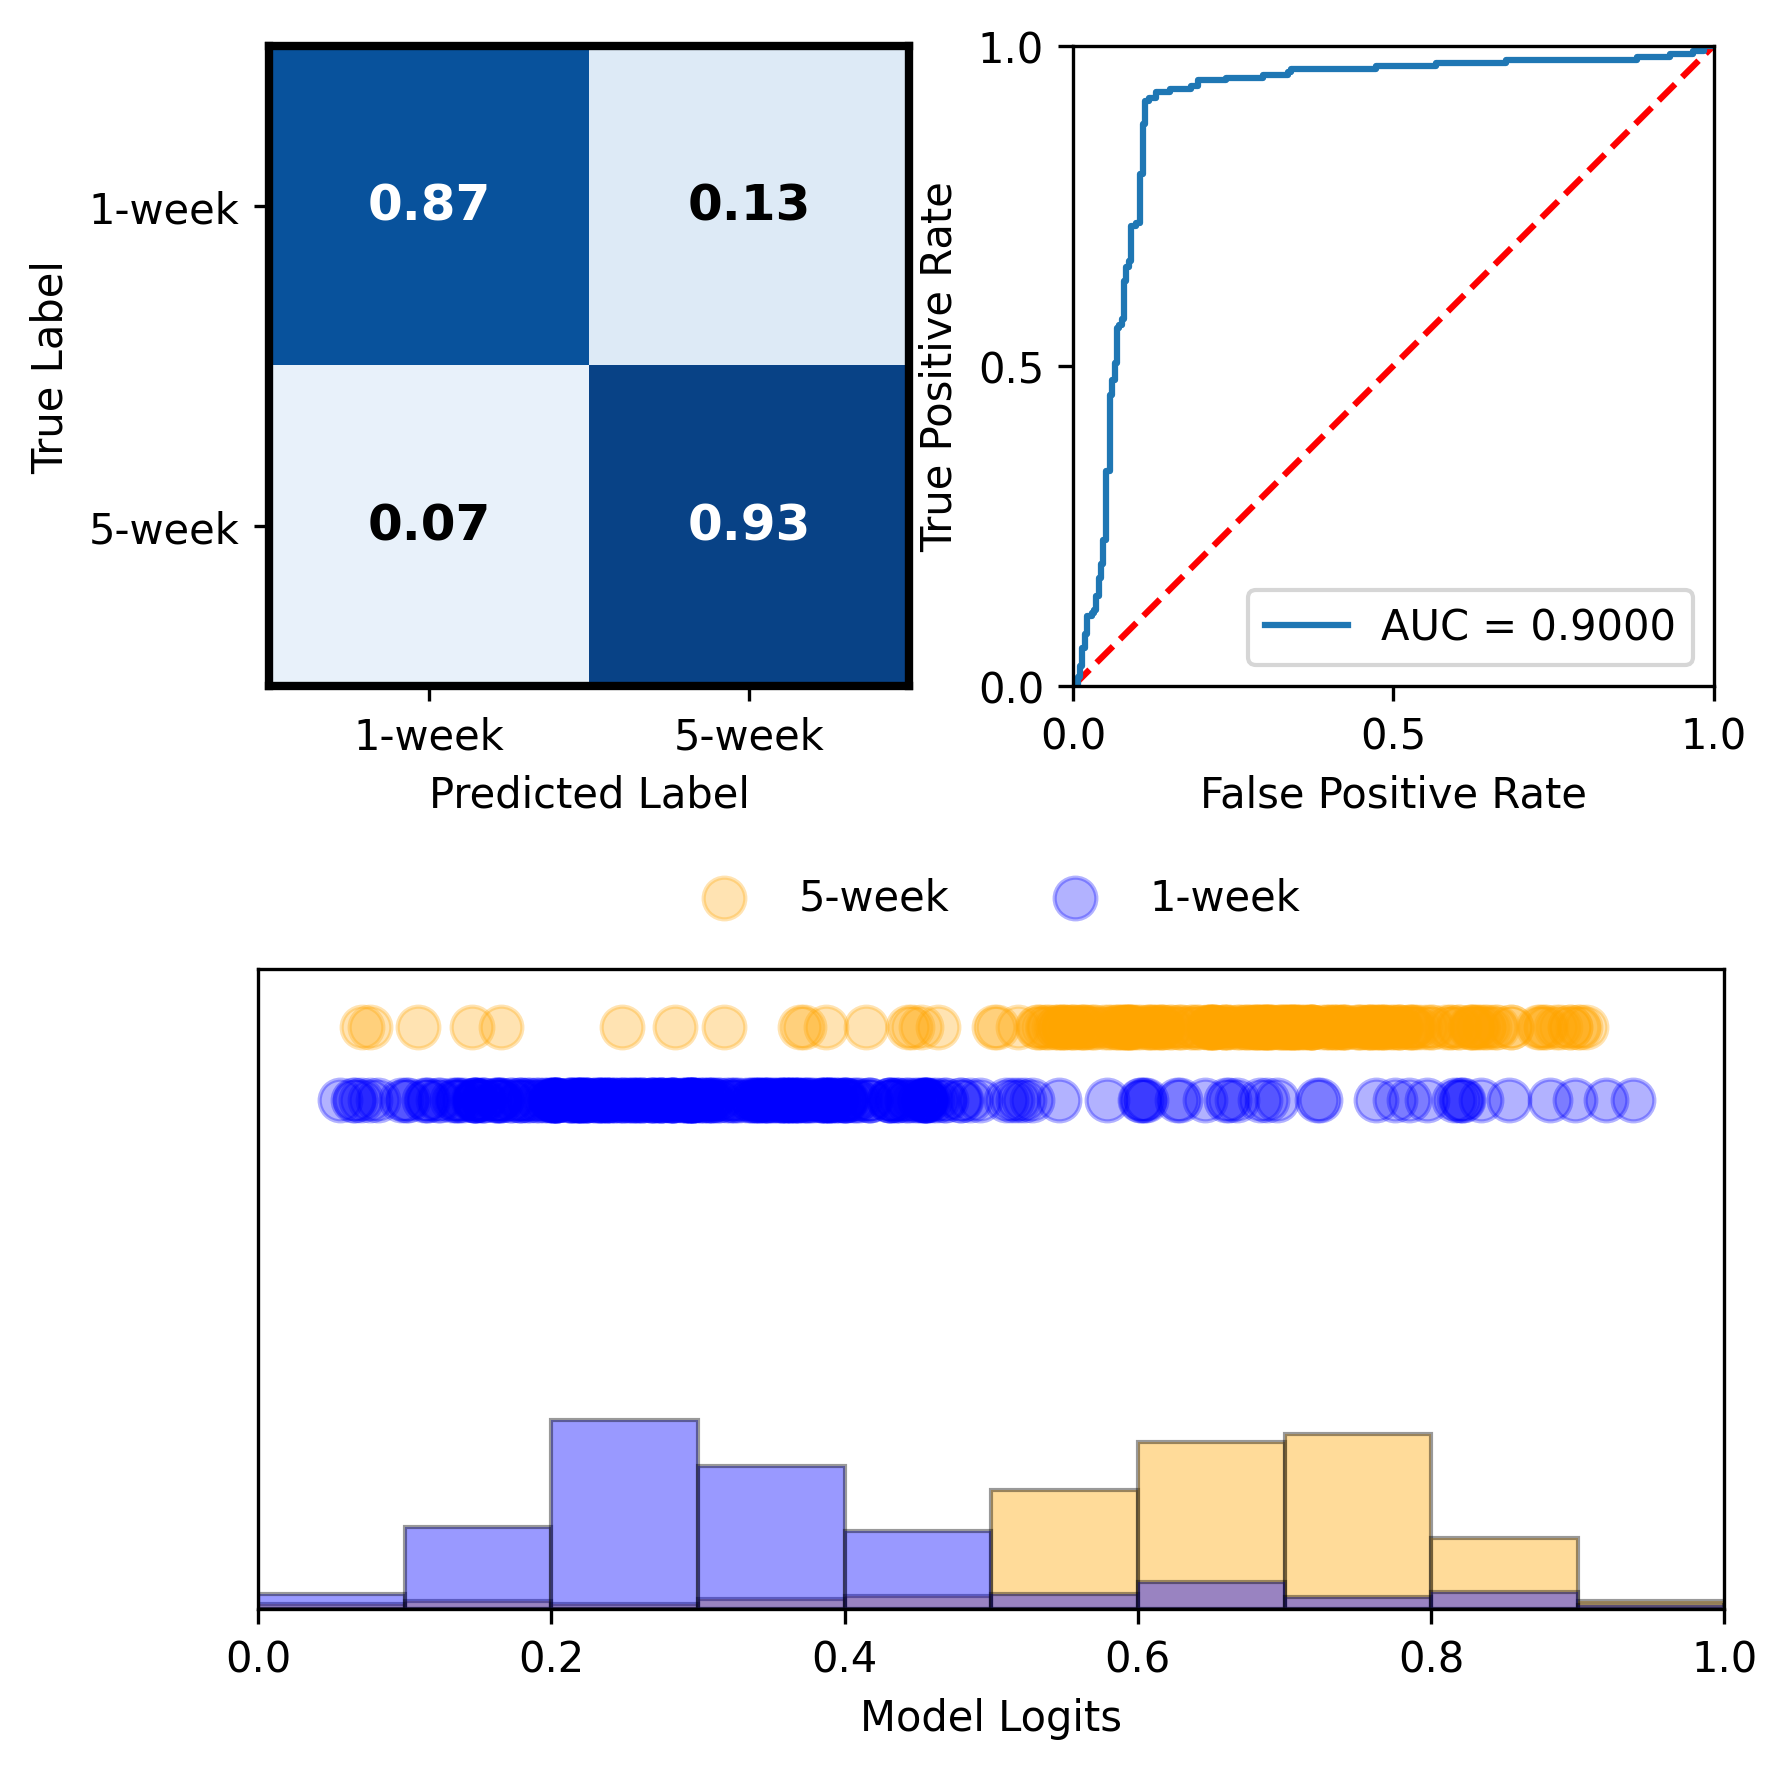


Saved: ./results_age_video_original/figures/Kfold_CMROCDist.png


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# === Step 0: Load Fold Data ===
df_data = pd.read_csv("./results_age_video_original/Updated_suplementary_aging_video.csv")

# === Step 1: Per-fold stats ===
fold_accs = []
fold_aucs = []

for fold in sorted(df_data["Fold"].unique()):
    fold_df = df_data[df_data["Fold"] == fold]
    fold_preds = fold_df["Raw_Pred"].to_numpy()
    fold_labels = fold_df["Label"].to_numpy()
    fold_binary = (fold_preds >= 0.5).astype(int)

    acc = accuracy_score(fold_labels, fold_binary)
    fpr_f, tpr_f, _ = roc_curve(fold_labels, fold_preds)
    auc_f = auc(fpr_f, tpr_f)

    fold_accs.append(acc)
    fold_aucs.append(auc_f)

print(f" Fold Accuracies: {fold_accs}")
print(f" Average Accuracy: {np.mean(fold_accs)}")
print(f" Fold AUCs: {fold_aucs}")
print(f" Average AUC: {np.mean(fold_aucs)}")

# === Step 2: Aggregate (pooled) predictions and labels from all folds ===
preds = df_data["Raw_Pred"].to_numpy()
labels = df_data["Label"].to_numpy()
binaryPred = (preds >= 0.5).astype(int)

overall_acc_mean_of_folds = np.mean(fold_accs)
overall_acc_pooled        = accuracy_score(labels, binaryPred)
fpr, tpr, _ = roc_curve(labels, preds)
overall_auc_pooled = auc(fpr, tpr)

print(f" Overall Test Accuracy (mean of folds): {overall_acc_mean_of_folds}")
print(f" Overall Test ROC AUC (from stacked preds): {overall_auc_pooled}")

# === Setup Plot ===
fig = plt.figure(figsize=(6, 6), dpi=300)
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# === Confusion Matrix — manual imshow, guaranteed text visibility ===
cm = confusion_matrix(labels, binaryPred, labels=[0, 1]).astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

ax1.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='equal')
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["1-week", "5-week"])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(["1-week", "5-week"])
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")

for i in range(2):
    for j in range(2):
        val = cm_norm[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center',
                  fontsize=12, fontweight='bold', color=color)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

# === ROC Curve ===
ax2.plot([0, 1], [0, 1], 'r--')
ax2.plot(fpr, tpr, label=f"AUC = {overall_auc_pooled:.4f}")
ax2.set_aspect('equal')
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1)
ax2.set_yticks([0, 0.5, 1])
ax2.set_xticks([0, 0.5, 1])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc="lower right")

# === Logit Distribution ===
h = 10
bins = np.linspace(0, 1, 11)

ax3.scatter(preds[labels == 1], h * np.ones_like(preds[labels == 1]),
            c='orange', alpha=0.3, s=100, label="5-week")
ax3.scatter(preds[labels == 0], h * 0.875 * np.ones_like(preds[labels == 0]),
            c='blue', alpha=0.3, s=100, label="1-week")

ax3.hist(preds[labels == 1], color='orange', alpha=0.4, bins=bins,
         density=True, edgecolor="black")
ax3.hist(preds[labels == 0], color='blue', alpha=0.4, bins=bins,
         density=True, edgecolor="black")

ax3.set_xlabel("Model Logits")
ax3.set_yticks([])
ax3.set_ylim(0, 1.1 * h)
ax3.set_xlim(0, 1)
ax3.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2,
            frameon=False, fontsize=10)

# === Save ===
os.makedirs("./results_age_video_original/figures", exist_ok=True)
plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.savefig("./results_age_video_original/figures/Kfold_CMROCDist.png", dpi=300)
plt.show()

print(f"\nSaved: ./results_age_video_original/figures/Kfold_CMROCDist.png")